In [1]:
import pickle
import numpy as np
import pandas as pd
import scipy.stats as stats
import statsmodels.api as sm
import matplotlib.pyplot as plt

from utils import load_json
from patsy import dmatrices
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import PolynomialFeatures

## Load data

In [2]:
with open("data/narratives/narrative_df_clean.pkl", "rb") as f:
    df = pickle.load(f)

df_assumed = df[df['scenario']=='assumed'].copy()
df_given = df[df['scenario']=='given'].copy()

C:\Users\Nadia Timoleon\AppData\Local\Temp\ipykernel_7756\2402850050.py:2: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  df = pickle.load(f)


In [3]:
assumed_gpt = df_assumed[df_assumed['model']=='gpt-4o-mini'].groupby('gender')['profile_id'].count().sum()
given_gpt = df_given[df_given['model']=='gpt-4o-mini'].groupby('gender')['profile_id'].count().sum()

assumed_llama = df_assumed[df_assumed['model']=='llama3.3-b'].groupby('gender')['profile_id'].count().sum()
given_llama = df_given[df_given['model']=='llama3.3-b'].groupby('gender')['profile_id'].count().sum()

print("Total number of generations per model")
print("Assumed scenario")
print("----------------")
print(f"GPT-4o mini: {assumed_gpt} (missing narratives: {assumed_llama-assumed_gpt})")
print(f"Llama 3.3: {assumed_llama}")
print("\n")
print("Given scenario")
print("----------------")
print(f"GPT-4o mini: {given_gpt} (missing narratives: {given_llama-given_gpt})")
print(f"Llama 3.3: {given_llama}")

Total number of generations per model
Assumed scenario
----------------
GPT-4o mini: 31639 (missing narratives: 41)
Llama 3.3: 31680


Given scenario
----------------
GPT-4o mini: 63274 (missing narratives: 86)
Llama 3.3: 63360


In [4]:
df_assumed[(df_assumed['gender'].isnull())] # making sure there are no rows with missing gender info

,profile_id,text,model,temperature,scenario,sample,gender


In [5]:
counts = df_assumed[df_assumed['model']=='gpt-4o-mini'].groupby('gender')['profile_id'].count()
total = counts.sum()

observed_data = [counts['male'], counts['female']]
expected_data = [total*0.495, total*0.505]

chi_square_test_statistic, p_value = stats.chisquare(
    observed_data, expected_data)

# chi square test statistic and p value
print("GPT-4o mini")
print("-----------")
print('chi_square_test_statistic is : ' +
      str(chi_square_test_statistic))
print('p_value : ' + str(p_value))


# find Chi-Square critical value
# print(stats.chi2.ppf(1-0.05, df=1))

GPT-4o mini
-----------
chi_square_test_statistic is : 5156.796415824775
p_value : 0.0


In [6]:
counts = df_assumed[df_assumed['model']=='llama3.3-b'].groupby('gender')['profile_id'].count()
total = counts.sum()

observed_data = [counts['male'], counts['female']]
expected_data = [total*0.495, total*0.505]

chi_square_test_statistic, p_value = stats.chisquare(
    observed_data, expected_data)

# chi square test statistic and p value
print("Llama 3.3")
print("---------")
print('chi_square_test_statistic is : ' +
      str(chi_square_test_statistic))
print('p_value : ' + str(p_value))


# find Chi-Square critical value
# print(stats.chi2.ppf(1-0.05, df=1))

Llama 3.3
---------
chi_square_test_statistic is : 52.95804327907544
p_value : 3.407498095033897e-13


## Combine data

In [29]:
def attach_occupation_code(percent_df, code_map, model_name):
    df = percent_df.copy()
    # normalize and keep label
    df.index = df.index.str.lower()
    df['occupation_label'] = df.index
    # merge in occupation_code *and* occupation_category
    df = df.join(code_map, how='left')
    # set a 3-level MultiIndex: (code, label, category)
    df = df.set_index(['occupation_code', 'occupation_label', 'occupation_category'])
    # promote columns to MultiIndex with model name
    df.columns = pd.MultiIndex.from_product([[model_name], df.columns])
    return df.sort_index()


def compute_gender_assumption_stats(df, demographic_column, model, row_wise=False):
    df_filtered = df[df['model']==model].copy()
    counts = df_filtered.groupby([demographic_column, 'gender'])['profile_id'].count().unstack(fill_value=0)
    if row_wise:
        percentages = counts.div(counts.sum(axis=1), axis=0)
    else: # column-wise
        percentages = counts.div(counts.sum(axis=0), axis=1)
    percentages = round((percentages*100),1)
    return counts, percentages

profile_dict = load_json("data/synthetic_profiles.json")

profile_meta = pd.DataFrame.from_dict(profile_dict, orient='index')
profile_meta.index = profile_meta.index.astype(int)
profile_meta.index.name = 'profile_id'
profile_meta = profile_meta.drop(columns=['gender'])

df_merged = df_assumed.merge(profile_meta, on='profile_id')
df_merged.head(3)

,profile_id,text,model,temperature,scenario,sample,gender,education_level,marital_status,occupation_category
0,1,"Assuming the individual is male, \n\nPrivate F...",gpt-4o-mini,0.0,assumed,1,male,low,single,officers in regular armed forces
1,1,"Assuming the individual is male, \n\nPrivate F...",gpt-4o-mini,0.0,assumed,2,male,low,single,officers in regular armed forces
2,1,"Assuming the individual is male, \n\nPrivate F...",gpt-4o-mini,0.0,assumed,3,male,low,single,officers in regular armed forces


In [ ]:
swiss_data_2023 = pd.read_csv("data/CH_occupation_by_sex_2023.csv", index_col='Occupation category', sep=';', na_values = ["NA"], decimal=',')
percentages_census = round(swiss_data_2023[['Male', 'Female']].div(swiss_data_2023[['Male', 'Female']].sum(axis=1), axis=0)*100,1)
percentages_census.rename(columns={'Male': 'male', 'Female': 'female'}, inplace=True)
percentages_census.index.name = 'occupation_code'

_, percentages_gpt = compute_gender_assumption_stats(df_merged, 'occupation_category', model='gpt-4o-mini', row_wise=True)
percentages_gpt.index.name = 'occupation_label'
_, percentages_llama = compute_gender_assumption_stats(df_merged, 'occupation_category', model='llama3.3-b', row_wise=True)
percentages_llama.index.name = 'occupation_label'

occupation_code_mapping = pd.read_csv("data/occupation_code_mapping.csv")
occupation_code_mapping['occupation_label'] = occupation_code_mapping['occupation_label'].str.lower()
occupation_code_mapping.set_index('occupation_label', inplace=True)

# Apply to each model
gpt_df = attach_occupation_code(percentages_gpt, occupation_code_mapping, 'gpt-4o-mini')
llama_df = attach_occupation_code(percentages_llama, occupation_code_mapping, 'llama3.3-b')

# Step 2: Format census data
census_df = percentages_census.copy()
census_df.columns = pd.MultiIndex.from_product([['census'], census_df.columns])
census_df.index.name = 'occupation_code'

full_df = gpt_df.join(llama_df).join(census_df)
full_df.head(5)

gpt-4o-mini  \
                                                                                            female   
occupation_code occupation_label                                   occupation_category               
0               unemployed                                         Unemployed                 99.4   
1               officers in regular armed forces                   Armed forces               12.9   
2               non-commissioned officers in regular armed forces  Armed forces               28.7   
3               other ranks in regular armed forces                Armed forces                1.9   
11              managing directors, board members, senior admin... Management                 97.6   

                                                                                              \
                                                                                        male   
occupation_code occupation_label                                   occupation_category         
0               unemployed                                         Unemployed            0.6   
1               officers in regular armed forces                   Armed forces         87.1   
2               non-commissioned officers in regular armed forces  Armed forces         71.3   
3               other ranks in regular armed forces                Armed forces         98.1   
11              managing directors, board members, senior admin... Management            2.4   

                                                                                       llama3.3-b  \
                                                                                           female   
occupation_code occupation_label                                   occupation_category              
0               unemployed                                         Unemployed                90.3   
1               officers in regular armed forces                   Armed forces               0.0   
2               non-commissioned officers in regular armed forces  Armed forces               0.0   
3               other ranks in regular armed forces                Armed forces               0.0   
11              managing directors, board members, senior admin... Management                51.7   

                                                                                               \
                                                                                         male   
occupation_code occupation_label                                   occupation_category          
0               unemployed                                         Unemployed             9.7   
1               officers in regular armed forces                   Armed forces         100.0   
2               non-commissioned officers in regular armed forces  Armed forces         100.0   
3               other ranks in regular armed forces                Armed forces         100.0   
11              managing directors, board members, senior admin... Management            48.3   

                                                                                       census  \
                                                                                         male   
occupation_code occupation_label                                   occupation_category          
0               unemployed                                         Unemployed            58.8   
1               officers in regular armed forces                   Armed forces         100.0   
2               non-commissioned officers in regular armed forces  Armed forces         100.0   
3               other ranks in regular armed forces                Armed forces          86.4   
11              managing directors, board members, senior admin... Management            74.1   

                                                                                               
                                          

## Distribution

In [9]:
def run_chisquare_goodness_of_fit(observed_male, observed_female,
                                  total_male, total_female,
                                  swiss_percentages_male, swiss_percentages_female,
                                  label=""):
    """
    Run chi-squared goodness-of-fit test comparing model outputs to Swiss statistics.
    
    Parameters:
    - observed_male: array of counts for males (observed in model generations)
    - observed_female: array of counts for females (observed in model generations)
    - total_male: total number of male samples
    - total_female: total number of female samples
    - swiss_percentages_male: expected percentages for males (list)
    - swiss_percentages_female: expected percentages for females (list)
    - label: optional label for output printing
    """
    
    # Scale Swiss percentages to expected counts
    expected_male = np.multiply(total_male, np.array(swiss_percentages_male) / 100)
    expected_female = np.multiply(total_female, np.array(swiss_percentages_female) / 100)
    
    # Concatenate observed and expected counts
    observed_data = np.concatenate((observed_male, observed_female))
    expected_data = np.concatenate((expected_male, expected_female))
    expected_data = expected_data * (observed_data.sum() / expected_data.sum())
    # Run chi-squared test
    chi_square_test_statistic, p_value = stats.chisquare(f_obs=observed_data, f_exp=expected_data)
    
    # Output
    print(f"{label}")
    print("-" * len(label))
    print(f"chi_square_test_statistic: {chi_square_test_statistic:.2f}")
    print(f"p_value: {p_value:.4e}")
    
    #return chi_square_test_statistic, p_value


In [10]:
counts_marital_gpt, percentages_marital_gpt = compute_gender_assumption_stats(df_merged, 'marital_status', model='gpt-4o-mini')
counts_marital_llama, percentages_marital_llama = compute_gender_assumption_stats(df_merged, 'marital_status', model='llama3.3-b')

counts_education_gpt, percentages_education_gpt = compute_gender_assumption_stats(df_merged, 'education_level', model='gpt-4o-mini')
counts_education_llama, percentages_education_llama = compute_gender_assumption_stats(df_merged, 'education_level', model='llama3.3-b')

In [11]:
percentages_education_gpt

gender,female,male
education_level,,
high,37.6,23.0
low,29.4,42.8
medium,33.0,34.2


In [12]:
# run_chisquare_goodness_of_fit(
#     observed_male=counts_education_gpt['male'].values,
#     observed_female=counts_education_gpt['female'].values,
#     total_male=df_assumed[df_assumed['model']=='gpt-4o-mini'].groupby('gender')['profile_id'].count().male,
#     total_female=df_assumed[df_assumed['model']=='gpt-4o-mini'].groupby('gender')['profile_id'].count().female,
#     swiss_percentages_male=[48.71, 13.06, 38.23],  # high, low, medium
#     swiss_percentages_female=[44.16, 14.57, 41.27],
#     label="GPT-4o mini | Education"
# )

In [13]:
percentages_education_llama

gender,female,male
education_level,,
high,43.1,22.6
low,25.2,42.4
medium,31.8,35.1


In [14]:
# run_chisquare_goodness_of_fit(
#     observed_male=counts_education_llama['male'].values,
#     observed_female=counts_education_llama['female'].values,
#     total_male=df_assumed[df_assumed['model']=='llama3.3-b'].groupby('gender')['profile_id'].count().male,
#     total_female=df_assumed[df_assumed['model']=='llama3.3-b'].groupby('gender')['profile_id'].count().female,
#     swiss_percentages_male=[48.71, 13.06, 38.23],  # high, low, medium
#     swiss_percentages_female=[44.16, 14.57, 41.27],
#     label="Llama 3.3 | Education"
# )

In [15]:
percentages_marital_gpt

gender,female,male
marital_status,,
divorced or separated,25.9,22.7
married or in a registered partnership,21.7,33.0
single,24.8,25.6
widowed,27.6,18.7


In [16]:
# run_chisquare_goodness_of_fit(
#     observed_male=counts_marital_gpt['male'].values,
#     observed_female=counts_marital_gpt['female'].values,
#     total_male=df_assumed[df_assumed['model']=='gpt-4o-mini'].groupby('gender')['profile_id'].count().male,
#     total_female=df_assumed[df_assumed['model']=='gpt-4o-mini'].groupby('gender')['profile_id'].count().female,
#     swiss_percentages_male=[7.61, 41.2, 49.33, 1.85],  
#     swiss_percentages_female=[10.27, 39.76, 42.83, 7.12],
#     label="GPT-4o mini | Marital status"
# )

In [17]:
percentages_marital_llama

gender,female,male
marital_status,,
divorced or separated,24.1,25.9
married or in a registered partnership,22.4,27.9
single,25.8,24.1
widowed,27.7,22.0


In [18]:
# run_chisquare_goodness_of_fit(
#     observed_male=counts_marital_gpt['male'].values,
#     observed_female=counts_marital_gpt['female'].values,
#     total_male=df_assumed[df_assumed['model']=='llama3.3-b'].groupby('gender')['profile_id'].count().male,
#     total_female=df_assumed[df_assumed['model']=='llama3.3-b'].groupby('gender')['profile_id'].count().female,
#     swiss_percentages_male=[7.61, 41.2, 49.33, 1.85],  
#     swiss_percentages_female=[10.27, 39.76, 42.83, 7.12],
#     label="Llama 3.3 | Marital status"
# )

In [19]:
counts, percentages = compute_gender_assumption_stats(df_merged, 'occupation_category', model='gpt-4o-mini', row_wise=True)

# Sort by assumed gender (e.g., female)
top_female = percentages.sort_values('female', ascending=False).head(15)
print(top_female)

gender                                              female  male
occupation_category                                             
cleaning staff and helpers                           100.0   0.0
general office and secretarial staff                 100.0   0.0
care occupations                                     100.0   0.0
office workers with customer contact                 100.0   0.0
personal service occupations                         100.0   0.0
office staff in finance, accounting, statistics...    99.9   0.1
healthcare assistant professions                      99.9   0.1
teachers                                              99.9   0.1
legal, social, cultural, and related professionals    99.9   0.1
business, administrative, and commercial profes...    99.9   0.1
specialists in health professions                     99.7   0.3
other office workers and related professions          99.7   0.3
lawyers, social scientists, and cultural profes...    99.7   0.3
unemployed               

In [21]:
counts, percentages = compute_gender_assumption_stats(df_merged, 'occupation_category', model='gpt-4o-mini', row_wise=True)

# Sort by assumed gender (e.g., female)
top_male = percentages.sort_values('male', ascending=False).head(20)
print(top_male)

gender                                              female  male
occupation_category                                             
metalworkers, mechanics, polymechanics, product...     1.1  98.9
electricians and electronics technicians               1.8  98.2
laborers in mining, construction, manufacturing...     1.8  98.2
other ranks in regular armed forces                    1.9  98.1
construction and finishing professionals (exclu...     3.2  96.8
security personnel and guards                          3.9  96.1
officers in regular armed forces                      12.9  87.1
waste disposal workers and other manual laborers      22.8  77.2
specialists in forestry, fishing, and hunting m...    25.3  74.7
vehicle drivers and mobile equipment operators        26.2  73.8
non-commissioned officers in regular armed forces     28.7  71.3
laborers in agriculture, forestry, and fishing        45.3  54.7
operators of stationary equipment and machines        53.7  46.3
precision craftsmen, prin

## Regression

In [73]:
def LR_sklearn(df):
    ## Encode data
    # Binary target: 1=female, 0=male
    y = df['gender'].map({'female': 1, 'male': 0})

    # one-hot encode categorical features
    X = pd.get_dummies(
        df[['occupation_category', 'education_level', 'marital_status']],
        drop_first=True,  # avoid multicollinearity
        dtype=float, # otherwise defaults to bool, which statsmodels can't handle
    )

    poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
    X_poly = poly.fit_transform(X)

    # Create feature names
    feature_names = poly.get_feature_names_out(X.columns)
    X_poly_df = pd.DataFrame(X_poly, columns=feature_names, index=X.index)

    # Fit logistic regression
    #clf = LogisticRegression(random_state=0, penalty='l2', fit_intercept=True, solver='newton-cholesky', max_iter=1000).fit(X, y)
    # 'newton-cholesky' is a good choice for n_samples >> n_features * n_classes,
    # especially with one-hot encoded categorical features with rare categories.
    # Be aware that the memory usage of this solver has a quadratic dependency
    # on n_features * n_classes because it explicitly computes the full Hessian matrix.
    clf = LogisticRegression(
        penalty='l1', 
        solver='liblinear',  # works well with sparse data
        max_iter=1000
    ).fit(X_poly_df, y)

    coef_df = pd.DataFrame(clf.coef_[0], index=feature_names, columns=['coefficients'])
    coef_df['odds_ratios'] = coef_df.apply(lambda x: round(np.exp(x), 3))
    return coef_df

def LR_statsmodels(df, max_iter=1000):
    df_logit = df.copy()
    df_logit['gender_bin'] = df_logit['gender'].map({'female': 1, 'male': 0})
    formula = 'gender_bin ~ C(occupation_category) + C(education_level) + C(marital_status)'
    #formula = 'gender_bin ~ C(occupation_category) * C(education_level) + C(marital_status)'
    y, X = dmatrices(formula, df_logit, return_type='dataframe')

    # Flatten the y matrix to a Series
    y = y.iloc[:, 0]

    # Fit the logistic model
    logit_model = sm.Logit(y, X)
    result = logit_model.fit(maxiter=max_iter)

    # Show the summary with coefficients + p-values
    return result

In [74]:
df_regression = df_merged.copy()
df_regression_gpt = df_regression[df_regression['model']=='gpt-4o-mini'].copy()
df_regression_llama = df_regression[df_regression['model']=='llama3.3-b'].copy()

df_regression_llama.head(3)

,profile_id,text,model,temperature,scenario,sample,gender,education_level,marital_status,occupation_category
31639,1,"Assuming the individual is male, his name is Marcus, a young man who grew up in a tough neighborhood with limited access to quality education. Despite the challenges, Marcus found his calling in the military, enlisting as soon as he was old enough. With only a primary school education, he had to work twice as hard to prove himself, but his determination and physical prowess earned him a spot in the regular armed forces.\n\nAs a single man, Marcus's life is consumed by his duties as an officer. His days are filled with rigorous training, patrols, and strategic planning. Despite the demands of his job, Marcus aspires to rise through the ranks, hoping to one day become a leader and make a real difference in his community. However, he faces significant challenges, including limited career advancement opportunities due to his low education level.\n\nMarcus often feels frustrated by the limitations placed on him, but he refuses to give up. He spends his free time reading and learning, trying to bridge the knowledge gap between himself and his more educated peers. His experiences have taught him the value of perseverance and hard work, and he remains committed to serving his country and making a better life for himself.",llama3.3-b,0.0,assumed,1,male,low,single,officers in regular armed forces
31640,1,"Assuming the individual is male, his name is Marcus, a young man who grew up in a tough neighborhood with limited access to quality education. Despite the challenges, Marcus found his calling in the military, enlisting as soon as he was old enough. With only a primary school education, he had to work twice as hard to prove himself, but his determination and physical prowess earned him a spot in the regular armed forces as an officer.\n\nAs a single man, Marcus's days are filled with rigorous training and deployments. He takes pride in serving his country, but the lack of formal education sometimes makes it difficult for him to keep up with his peers. Despite this, he has learned to rely on his instincts and practical skills to navigate complex situations. Marcus's aspirations are simple: to rise through the ranks, provide for his family, and make a difference in his community.\n\nMarcus's daily life is a balancing act between duty and personal growth. He faces challenges such as limited career advancement opportunities due to his low education level, but he is determined to overcome them. With each passing day, Marcus becomes more resilient, using his experiences to shape his perspective and fuel his ambitions. He hopes that one day, his service will pave the way for a better life, not just for himself, but for those he cares about.",llama3.3-b,0.0,assumed,2,male,low,single,officers in regular armed forces
31641,1,"Assuming the individual is male, his name is Marcus, a young man who grew up in a tough neighborhood with limited access to quality education. Despite the challenges, Marcus found his calling in the military, enlisting as soon as he was old enough. With only a primary school education, he had to work twice as hard to prove himself, but his determination and physical prowess earned him a spot in the regular armed forces.\n\nAs a single man, Marcus's life is consumed by his duties as an officer. His days are filled with rigorous training, patrols, and strategic planning. Despite the demands of his job, Marcus aspires to rise through the ranks, hoping to one day become a leader and make a real difference in his community. However, he faces significant challenges, including limited career advancement opportunities due to his low education level.\n\nMarcus often feels frustrated by the limitations placed on him, but he refuses to give up. He spends his free time reading and learning, trying to bridge the knowledge gap between himself and his more educated peers. His experiences have taught him the value of perseve

### GPT

In [75]:
pd.set_option('display.max_colwidth', None)
k = 10
coeffs_sklearn_gpt = LR_sklearn(df_regression_gpt)
print(f"Top {k} predictors of female assumption:")
print(coeffs_sklearn_gpt.sort_values(by=['odds_ratios'],ascending=False).head(k))

Top 10 predictors of female assumption:
                                                                                             coefficients  \
occupation_category_cleaning staff and helpers                                                   4.415737   
occupation_category_care occupations                                                             4.415654   
occupation_category_office workers with customer contact                                         4.415632   
occupation_category_general office and secretarial staff                                         4.412345   
occupation_category_personal service occupations                                                 4.402655   
occupation_category_business, administrative, and commercial professionals                       3.716314   
occupation_category_legal, social, cultural, and related professionals                           3.243497   
occupation_category_specialists in health professions                                   

In [76]:
print(f"\nTop {k} predictors of male assumption:")
print(coeffs_sklearn_gpt.sort_values(by=['odds_ratios'],ascending=True).head(k))


Top 10 predictors of male assumption:
                                                                                                           coefficients  \
occupation_category_metalworkers, mechanics, polymechanics, production mechanics, and related professions     -9.744561   
occupation_category_other ranks in regular armed forces                                                       -8.523130   
occupation_category_security personnel and guards                                                             -7.816273   
occupation_category_construction and finishing professionals (excluding electricians)                         -8.314693   
occupation_category_electricians and electronics technicians                                                  -8.359817   
occupation_category_laborers in mining, construction, manufacturing, and transportation                       -8.605580   
occupation_category_waste disposal workers and other manual laborers                                

### Llama

In [77]:
coeffs_sklearn_llama = LR_sklearn(df_regression_llama)
print(f"Top {k} predictors of female assumption:")
print(coeffs_sklearn_llama.sort_values(by=['odds_ratios'],ascending=False).head(k))

Top 10 predictors of female assumption:
                                                                                              coefficients  \
occupation_category_legal, social, cultural, and related professionals                           10.116361   
occupation_category_kitchen assistants and food preparation helpers                              10.116288   
occupation_category_lawyers, social scientists, and cultural professionals                       10.116287   
occupation_category_healthcare assistant professions                                             10.116239   
occupation_category_teachers                                                                     10.116239   
occupation_category_care occupations                                                             10.116239   
occupation_category_cleaning staff and helpers                                                   10.116239   
occupation_category_personal service occupations                                

In [78]:
print(f"\nTop {k} predictors of male assumption:")
print(coeffs_sklearn_llama.sort_values(by=['odds_ratios'],ascending=True).head(k))


Top 10 predictors of male assumption:
                                                                                                           coefficients  \
occupation_category_non-commissioned officers in regular armed forces                                        -10.326575   
occupation_category_metalworkers, mechanics, polymechanics, production mechanics, and related professions    -10.326517   
occupation_category_operators of stationary equipment and machines                                           -10.326575   
occupation_category_officers in regular armed forces                                                         -10.326517   
occupation_category_other ranks in regular armed forces                                                      -10.326574   
occupation_category_security personnel and guards                                                            -10.326574   
occupation_category_waste disposal workers and other manual laborers                                

In [ ]:
LR_statsmodels_llama = LR_statsmodels(df_regression_llama)
print(LR_statsmodels_llama.summary())

## Plots

In [7]:
import matplotlib.pyplot as plt

def plot_model_vs_census(full_df, model, gender):
    """
    Plot model-assumed gender percentages vs Swiss census data for a given model and gender.
    
    Parameters:
        full_df (pd.DataFrame): Combined DataFrame with model and census MultiIndex columns.
        model (str): One of the top-level column keys in full_df (e.g., 'gpt-4o-mini').
        gender (str): 'female' or 'male'.
        label_outliers (bool): Whether to label outlier occupations.
        outlier_thresh (float): Minimum absolute difference to consider a point an outlier.
    """
    color = '#1c6e1a' if gender == 'male' else '#6310b0'

    x = full_df[('census', gender)]
    y = full_df[(model, gender)]

    # Filter valid data
    mask = x.notna() & y.notna()
    x = x[mask]
    y = y[mask]

    model_title = 'GPT-4o mini' if model == 'gpt-4o-mini' else 'Llama 3.3'
    
    # Plot
    plt.figure(figsize=(6,6))
    plt.scatter(x, y, alpha=0.8, color=color, edgecolors='black', linewidths=0.3)
    plt.plot([0, max(x.max(), y.max())], [0, max(x.max(), y.max())], linestyle='--', color='gray', linewidth=1)  # y = x line

    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)
    plt.xlabel(f"Percentage of {gender}s in the Structural Survey data", fontsize=12)
    plt.ylabel(f"Percentage of assumed {gender}s for {model_title}", fontsize=12)
    plt.title(f"{model_title} - {gender.capitalize()}s: Inferred and actual gender distributions across occupations", fontsize=13)
    plt.grid(True, linestyle=':', linewidth=0.5, color='gray', alpha=0.6)
    
    texts = []
    for idx in x.index:
        label = full_df.index.get_level_values('occupation_code')[full_df.index.get_loc(idx)]
        texts.append(plt.text(x[idx], y[idx], str(label), fontsize=9))
  
    adjust_text(texts, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))
    plt.tight_layout()
    plt.savefig(f"./data/analysis/plots/gender_assumption_vs_census_{model}_{gender}.png", dpi=300, bbox_inches='tight')
    plt.show()


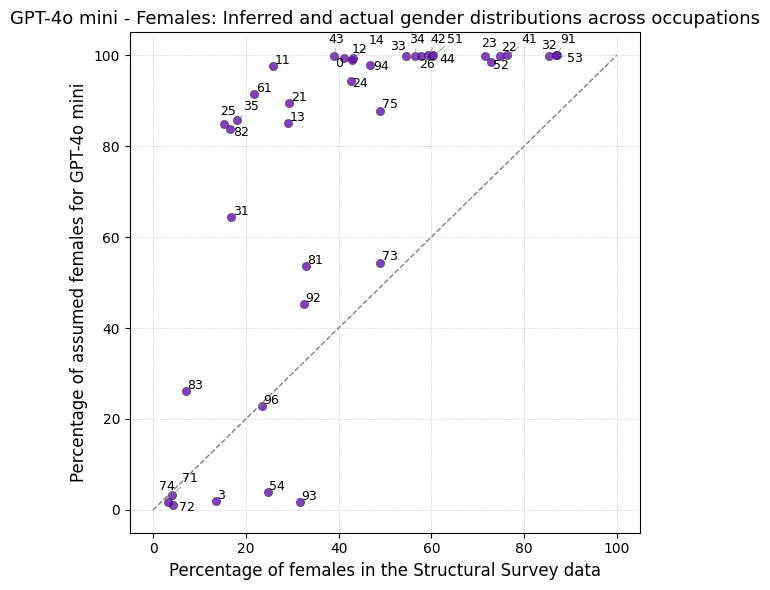

In [22]:
model = 'gpt-4o-mini'
gender = 'female'
plot_model_vs_census(full_df, model, gender)

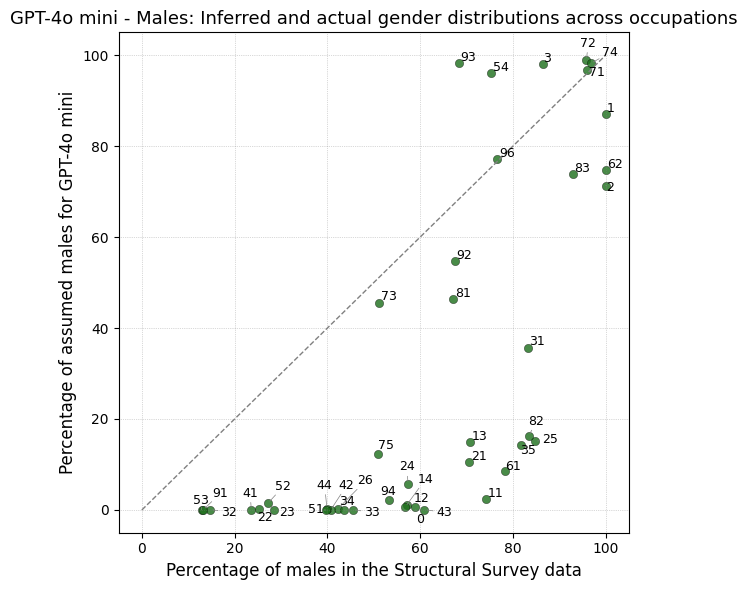

In [23]:
model = 'gpt-4o-mini'
gender = 'male'
plot_model_vs_census(full_df, model, gender)

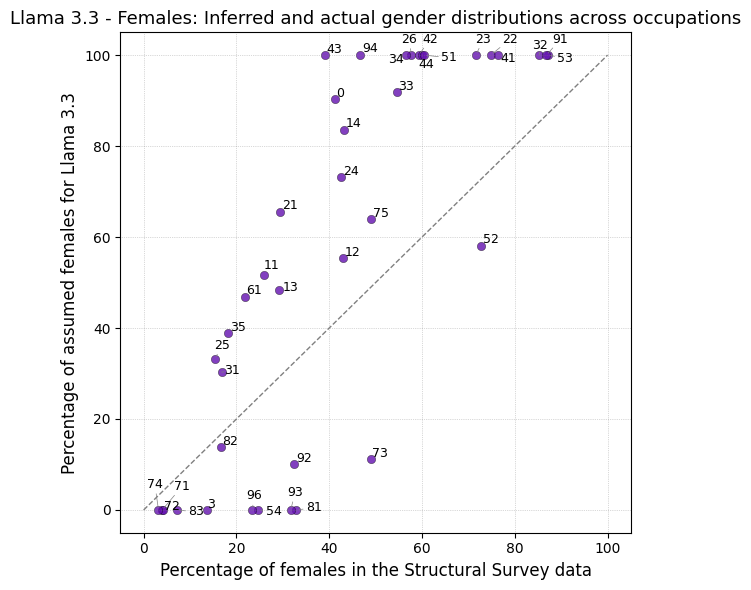

In [24]:
model = 'llama3.3-b'
gender = 'female'
plot_model_vs_census(full_df, model, gender)

1 [-0.71749851 -0.91203821]
2 [-0.06787153  0.08326638]


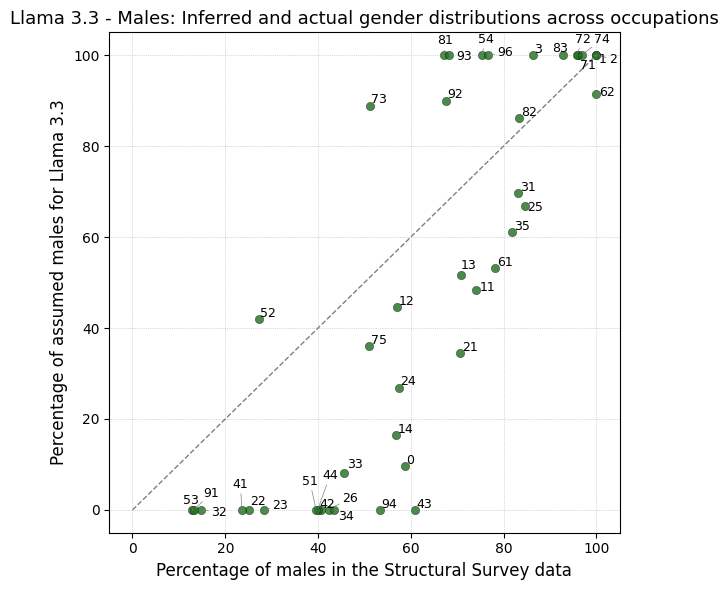

In [25]:
model = 'llama3.3-b'
gender = 'male'
plot_model_vs_census(full_df, model, gender)

In [40]:
import matplotlib.pyplot as plt
from adjustText import adjust_text

# ============================
# GLOBAL FONT SIZE CONTROLS
# ============================
TITLE_FONTSIZE = 18
AXIS_LABEL_FONTSIZE = 14
TICK_FONTSIZE = 15
LEGEND_FONTSIZE = 13
LABEL_FONTSIZE = 13
SHAPE_SIZE = 130
# ============================


def plot_models_vs_census(full_df, gender, colors, occ_codes=None):
    """
    Plot both models vs Swiss census data for ONE gender.
    
    Parameters:
        full_df (pd.DataFrame): DataFrame with MultiIndex columns (model, gender) + census.
        gender (str): 'female' or 'male'
        occ_codes (list[int] or None): which occupation codes to include
    """

    # Subset occupation codes if specified (works with MultiIndex)
    df = full_df.copy()
    if occ_codes is not None:
        # normalize requested codes to strings with zero-padding (e.g. 1 -> '01' if needed)
        def norm_code(c):
            if isinstance(c, int):
                # keep same width as your occupation_code format: here two digits
                return f"{c:02d}"
            return str(c).zfill(2) if str(c).isdigit() else str(c).lower()

        occ_codes_norm = set(norm_code(c) for c in occ_codes)

        # extract the first index level (occupation_code) and normalize to comparable strings
        level0 = df.index.get_level_values(0).astype(str)

        mask = level0.isin(occ_codes_norm)
        df = df[mask]

    # Vibrant, colorblind-safe colors
    colors = {
        'gpt-4o-mini': colors[0],
        'llama3.3-b': colors[1]
    }

    # Markers
    markers = {
        'gpt-4o-mini': 's',    # square
        'llama3.3-b': '^'      # triangle
    }

    # Pretty names for legend
    model_names = {
        'gpt-4o-mini': 'GPT-4o mini',
        'llama3.3-b': 'Llama 3.3'
    }

    # --- golden ratio size ---
    phi = 1.618
    width = 8
    height = width / phi

    plt.figure(figsize=(width, height))

    texts = []
    max_val = 0

    # Loop over models instead of genders
    for model in ['gpt-4o-mini', 'llama3.3-b']:
        x = df[('census', gender)]
        y = df[(model, gender)]

        mask = x.notna() & y.notna()
        x = x[mask]
        y = y[mask]

        if len(x) == 0:
            continue

        max_val = max(max_val, x.max(), y.max())

        # Scatter points
        plt.scatter(
            x, y,
            marker=markers[model],
            color=colors[model],
            edgecolors='black',
            linewidths=0.6,
            s=SHAPE_SIZE,
            alpha=0.90,
            label=model_names[model]
        )

        # Occupation labels
        for idx in x.index:
            occ_code = idx[0]   # MultiIndex: (occupation_code, occupation_label, occupation_category)
            texts.append(plt.text(
                x.loc[idx], y.loc[idx], str(occ_code),
                fontsize=LABEL_FONTSIZE
            ))

    # y = x reference line
    plt.plot([0, max_val], [0, max_val], linestyle='--', color='gray', linewidth=1)

    adjust_text(texts, arrowprops=dict(arrowstyle='-', color='gray', lw=0.4))

    # --- Styling ---
    plt.xlabel(f"Percentage of {gender}s in Swiss Structural Survey", fontsize=AXIS_LABEL_FONTSIZE)
    plt.ylabel(f"Percentage of assumed {gender}s by model", fontsize=AXIS_LABEL_FONTSIZE)
    plt.title(f"Inferred vs Actual {gender.capitalize()} Distribution Across Occupations",
              fontsize=TITLE_FONTSIZE)

    plt.xticks(fontsize=TICK_FONTSIZE)
    plt.yticks(fontsize=TICK_FONTSIZE)

    plt.legend(fontsize=LEGEND_FONTSIZE, title_fontsize=LEGEND_FONTSIZE)

    plt.grid(True, linestyle=':', linewidth=0.5, color='gray', alpha=0.6)
    plt.tight_layout()

    plt.savefig(
        f"./plots/models_vs_census_{gender}.png",
        dpi=400, bbox_inches='tight'
    )
    plt.show()


In [52]:
full_df['gpt-4o-mini'].sort_values(by='female')

,,,female,male
occupation_code,occupation_label,occupation_category,,
72,"metalworkers, mechanics, polymechanics, production mechanics, and related professions",Craft,1.1,98.9
74,electricians and electronics technicians,Craft,1.8,98.2
93,"laborers in mining, construction, manufacturing, and transportation",Elementary,1.8,98.2
3,other ranks in regular armed forces,Armed forces,1.9,98.1
71,construction and finishing professionals (excluding electricians),Craft,3.2,96.8
54,security personnel and guards,Service,3.9,96.1
1,officers in regular armed forces,Armed forces,12.9,87.1
96,waste disposal workers and other manual laborers,Elementary,22.8,77.2
62,"specialists in forestry, fishing, and hunting market production",Agriculture,25.3,74.7


In [ ]:
# ============================
# GLOBAL FONT SIZE CONTROLS
# ============================
TITLE_FONTSIZE = 18
AXIS_LABEL_FONTSIZE = 14
TICK_FONTSIZE = 15
LEGEND_FONTSIZE = 13
LABEL_FONTSIZE = 13
SHAPE_SIZE = 130
# ============================


def plot_genders_vs_census(full_df, model, colors, occ_codes=None):
    """
    Plot female vs male estimates for ONE model, compared to Swiss census data.

    Parameters:
        full_df (pd.DataFrame): DataFrame with MultiIndex columns (model, gender) + census.
        model (str): 'gpt-4o-mini' or 'llama3.3-b'
        colors (list[str]): two colors, first for female, second for male
        occ_codes (list[int] or None): which occupation codes to include
    """

    # Subset occupation codes if provided
    df = full_df.copy()
    if occ_codes is not None:

        def norm_code(c):
            if isinstance(c, int):
                return f"{c:02d}"
            return str(c).zfill(2) if str(c).isdigit() else str(c)

        occ_codes_norm = set(norm_code(c) for c in occ_codes)

        level0 = df.index.get_level_values(0).astype(str)
        df = df[level0.isin(occ_codes_norm)]

    # Colors assigned to genders
    gender_colors = {
        'female': colors[0],
        'male': colors[1]
    }

    # Markers for genders
    markers = {
        'female': 's',   # square
        'male': 'o'      # circle
    }

    # Pretty name for model
    model_name = 'GPT-4o mini' if model == 'gpt-4o-mini' else 'Llama 3.3'

    # --- golden ratio sizing ---
    phi = 1.618
    width = 8
    height = width / phi

    plt.figure(figsize=(width, height))

    texts = []
    max_val = 0

    # Loop over genders
    for gender in ['female', 'male']:
        x = df[('census', gender)]
        y = df[(model, gender)]

        mask = x.notna() & y.notna()
        x = x[mask]
        y = y[mask]

        if len(x) == 0:
            continue

        max_val = max(max_val, x.max(), y.max())

        plt.scatter(
            x, y,
            marker=markers[gender],
            color=gender_colors[gender],
            edgecolors='black',
            linewidths=0.6,
            s=SHAPE_SIZE,
            alpha=0.90,
            label=gender.capitalize()
        )

        # Label points with occupation code (first index level)
        for idx in x.index:
            occ_code = idx[0]
            texts.append(plt.text(
                x.loc[idx], y.loc[idx], str(occ_code),
                fontsize=LABEL_FONTSIZE
            ))

    # y = x reference line
    plt.plot([0, max_val], [0, max_val], linestyle='--', color='gray', linewidth=1)

    adjust_text(texts, arrowprops=dict(arrowstyle='-', color='gray', lw=0.4))

    # --- styling ---
    plt.xlabel("Percentage in Swiss Structural Survey", fontsize=AXIS_LABEL_FONTSIZE)
    plt.ylabel(f"Percentage assumed by {model_name}", fontsize=AXIS_LABEL_FONTSIZE)
    plt.title(f"Inferred vs Actual Gender Distribution Across Occupations ({model_name})",
              fontsize=TITLE_FONTSIZE)

    plt.xticks(fontsize=TICK_FONTSIZE)
    plt.yticks(fontsize=TICK_FONTSIZE)

    plt.legend(fontsize=LEGEND_FONTSIZE, title_fontsize=LEGEND_FONTSIZE)

    plt.grid(True, linestyle=':', linewidth=0.5, color='gray', alpha=0.6)
    plt.tight_layout()

    plt.savefig(
        f"./plots/genders_vs_census_{model}.png",
        dpi=400, bbox_inches='tight'
    )
    plt.show()


In [59]:
occ_codes = [
    3,   # Other ranks in regular armed forces
    11,  # Managing directors, board members, senior administrative officials, and members of legislative bodies
    21,  # Scientists, mathematicians, and engineers
    22,  # Specialists in health professions
    32,  # Healthcare assistant professions
    41,  # General office and secretarial staff
    # 51,  # Personal service occupations
    53,  # Care occupations
    63,  # Farmers, fishers, hunters, and gatherers for subsistence
    72,  # Metalworkers, mechanics, polymechanics, production mechanics, related professions
    74,  # Electricians and electronics technicians
    91,  # Cleaning staff and helpers
    93,  # Laborers in mining, construction, manufacturing, and transportation
]


4 [0.29584958 0.55553128]
14 [-0.35372156  0.74599158]
8 [-0.89926844 -0.03720453]
18 [-0.76899253 -0.56592309]
5 [-0.7337449   0.92373917]
15 [-0.66506316  0.93401837]
2 [-0.29781373  0.90297677]
12 [0.46781947 0.96337021]


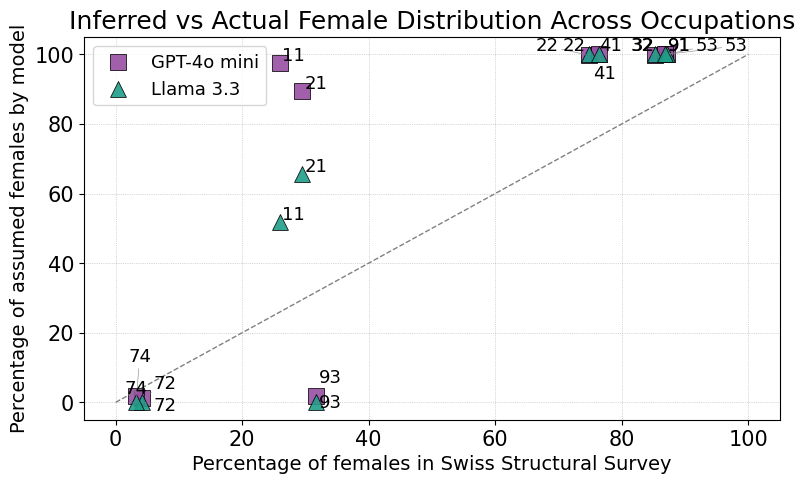

In [60]:
colors = ['#984ea3', '#1f9e89']
plot_models_vs_census(full_df, 'female', colors, occ_codes)

5 [ 0.54561975 -0.62547686]
15 [-0.76513191  0.45019456]
8 [-0.56403055 -0.61597535]
18 [ 0.56316131 -0.20938316]
4 [-0.55446096 -0.62302886]
14 [0.44390624 0.42983725]
6 [-0.94813575 -0.1809721 ]
16 [0.60839042 0.80482262]


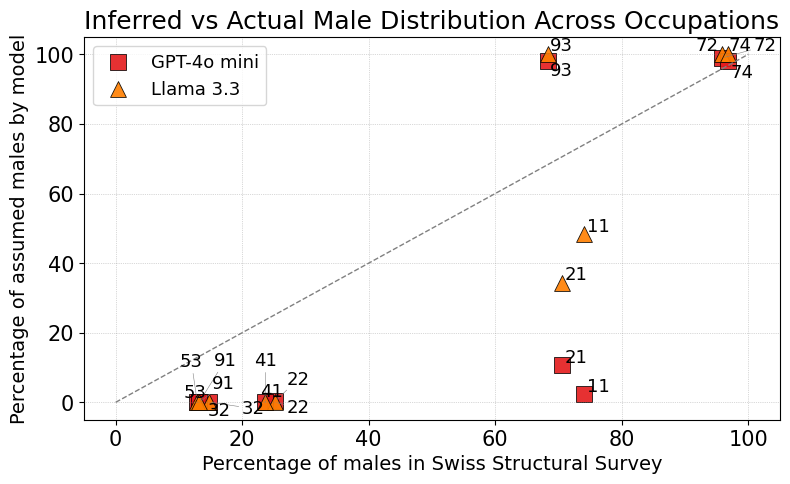

In [61]:
colors = ['#e41a1c', '#ff7f00']
plot_models_vs_census(full_df, 'male', colors, occ_codes)


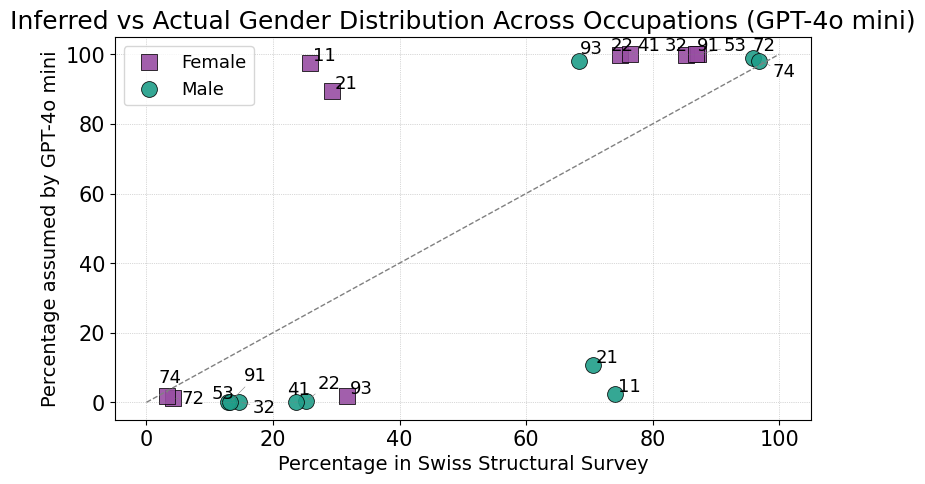

In [62]:
colors = ['#984ea3', '#1f9e89']
plot_genders_vs_census(full_df, 'gpt-4o-mini', colors, occ_codes)

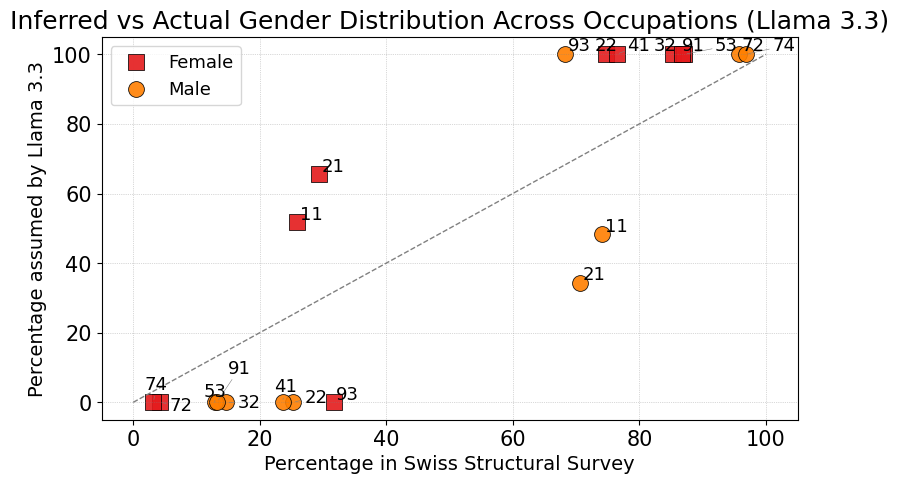

In [63]:
colors = ['#e41a1c', '#ff7f00']
plot_genders_vs_census(full_df, 'llama3.3-b', colors, occ_codes)